## Isolation Forest

Isolation Forest is similar to Random Forest because both methods are based on decision trees. However, unlike supervised learning algorithms, Isolation Forest does not use pre-defined labels, making it an unsupervised learning technique.

The algorithm is based on the principle that anomalies are observations that are both rare and significantly different from the majority of the data.

In Isolation Forest, randomly selected subsets of the data are recursively divided using randomly chosen features and split values, forming a tree structure.

Data points that move deeper into the tree are less likely to be anomalies because more splits are required to isolate them. In contrast, observations that appear in shorter branches are more likely to be anomalies, as they can be separated from the rest of the data more easily.

### Importing required libraries

In [1]:
import numpy as np 
import pandas as pd
import seaborn as sns
from sklearn.metrics import classification_report,accuracy_score
from sklearn.ensemble import IsolationForest
import matplotlib.pyplot as plt

### Importing the credit card transactional dataset

In [2]:
transaction_data = pd.read_csv("../Data/credit_card_transactional_data.csv")
transaction_data.head(10)

,Timestamp,Value,C1,C2,C3,C4,C5,C6,C7,C8,C9,C10,C11,C12,Class
0,152212.22220,1.816,13.245219,NaN,16.367516,0.029326,1.278423,2.748137,-1.331457,0.065879,-0.104518,-0.037517,-250.000000,-0.475633,0
1,159074.44440,163.568,4.401403,0.084682,-313.000000,0.001888,-0.103762,1.115678,NaN,0.062966,0.130546,-0.303582,NaN,NaN,0
2,43127.77778,24.000,-9.067399,0.762501,NaN,0.052481,-0.101681,-88.000000,0.117912,NaN,0.358812,-0.367016,NaN,361.000000,0
3,156042.22220,8.000,8.728304,-0.382673,NaN,-0.116056,-0.122346,-44.000000,-338.000000,0.042154,-0.261259,-0.103974,NaN,-1.654373,0
4,154720.00000,59.496,7.657141,0.150611,NaN,-0.034883,0.826100,0.357556,0.147640,NaN,0.080491,-0.693792,-0.308631,0.563570,0
5,37515.55556,7.192,-6.944700,-0.136388,0.543172,-0.024708,0.112116,1.647884,-0.003729,0.039702,0.097664,-0.341836,-274.000000,-0.056484,0
6,34078.88889,10.320,133.000000,-0.540177,8.803812,-0.007307,-67.000000,1.709944,-0.316351,-0.003741,0.187718,NaN,0.338621,0.227839,0
7,58923.33333,1.584,-0.670264,-0.164626,-8.848897,0.002278,0.078981,1.143923,-472.000000,0.010555,0.065275,0.029735,-0.396261,-0.182626,0
8,166341.11110,100.000,1.984216,0.416604,-178.000000,-0.003641,53.000000,NaN,0.109451,0.022316,-0.039217,0.438853,-0.184313,0.643273,0
9,175154.44440,0.712,5.857276,-0.073466,0.667938,-0.000891,-0.012069,1.427191,-101.000000,-0.038324,0.014183,-0.109039,0.420946,-61.000000,0


In [3]:
transaction_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 140000 entries, 0 to 139999
Data columns (total 15 columns):
 #   Column     Non-Null Count   Dtype  
---  ------     --------------   -----  
 0   Timestamp  140000 non-null  float64
 1   Value      140000 non-null  float64
 2   C1         116232 non-null  float64
 3   C2         129731 non-null  float64
 4   C3         129693 non-null  float64
 5   C4         140000 non-null  float64
 6   C5         129678 non-null  float64
 7   C6         116529 non-null  float64
 8   C7         125595 non-null  float64
 9   C8         129645 non-null  float64
 10  C9         140000 non-null  float64
 11  C10        129891 non-null  float64
 12  C11        125695 non-null  float64
 13  C12        125833 non-null  float64
 14  Class      140000 non-null  int64  
dtypes: float64(14), int64(1)
memory usage: 16.0 MB


In [4]:
transaction_data['Class'].value_counts()

Class
0    139747
1       253
Name: count, dtype: int64

<Axes: xlabel='Class', ylabel='count'>

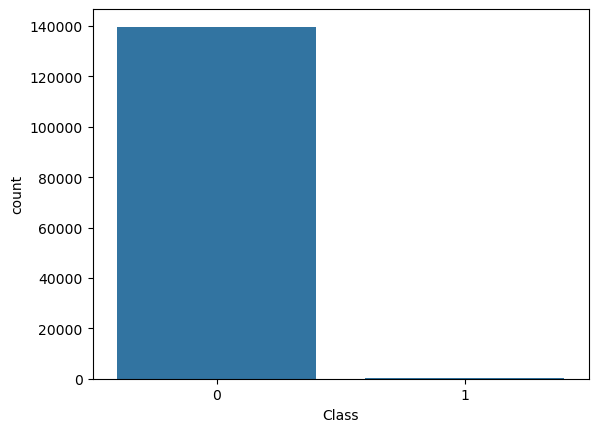

In [5]:
sns.countplot(x='Class',data=transaction_data)

### Lets get more details about the data 

In [6]:
transaction_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 140000 entries, 0 to 139999
Data columns (total 15 columns):
 #   Column     Non-Null Count   Dtype  
---  ------     --------------   -----  
 0   Timestamp  140000 non-null  float64
 1   Value      140000 non-null  float64
 2   C1         116232 non-null  float64
 3   C2         129731 non-null  float64
 4   C3         129693 non-null  float64
 5   C4         140000 non-null  float64
 6   C5         129678 non-null  float64
 7   C6         116529 non-null  float64
 8   C7         125595 non-null  float64
 9   C8         129645 non-null  float64
 10  C9         140000 non-null  float64
 11  C10        129891 non-null  float64
 12  C11        125695 non-null  float64
 13  C12        125833 non-null  float64
 14  Class      140000 non-null  int64  
dtypes: float64(14), int64(1)
memory usage: 16.0 MB


In [7]:
transaction_data.describe()

,Timestamp,Value,C1,C2,C3,C4,C5,C6,C7,C8,C9,C10,C11,C12,Class
count,140000.000000,140000.000000,116232.000000,129731.000000,129693.000000,140000.000000,129678.000000,116529.000000,125595.000000,129645.000000,140000.000000,129891.000000,125695.000000,125833.000000,140000.000000
mean,105334.592698,71.102883,-13.647954,-15.797094,-16.141105,0.000037,-15.540173,-13.681959,-14.760374,-16.067148,0.000119,-16.029764,-15.500080,-15.491673,0.001807
std,52763.641695,212.359700,224.599903,72.631165,74.585111,0.031540,72.120519,230.871123,235.313604,73.148242,0.215636,73.378542,237.289210,236.485713,0.042472
min,0.000000,0.000000,-2000.000000,-500.000000,-500.000000,-0.212540,-500.000000,-2000.000000,-1999.000000,-500.000000,-1.544515,-500.000000,-1998.000000,-2000.000000,0.000000
25%,60107.500002,4.400000,-6.419730,-0.262951,-9.288367,-0.017731,-0.205542,-1.149444,-0.108129,-0.033800,-0.143551,-0.509781,-0.277642,-0.596404,0.000000
50%,94276.111110,17.584000,-1.250014,-0.019520,-1.739613,-0.000140,0.000903,0.279868,0.023023,-0.005629,0.003731,-0.062414,-0.019975,0.007491,0.000000
75%,154845.833375,61.522000,5.063801,0.220734,6.436411,0.017776,0.206203,1.092373,0.109777,0.022194,0.140835,0.327266,0.224548,0.507399,0.000000
max,191985.555600,20552.928000,2000.000000,100.000000,196.401291,0.278668,100.000000,1999.000000,1998.000000,100.000000,0.858579,100.000000,2000.000000,1999.000000,1.000000


### How many null values are present?

In [8]:
transaction_data.isnull().sum()

Timestamp        0
Value            0
C1           23768
C2           10269
C3           10307
C4               0
C5           10322
C6           23471
C7           14405
C8           10355
C9               0
C10          10109
C11          14305
C12          14167
Class            0
dtype: int64

### Imputing null values with median so that it doesnt get affected by outliers

In [9]:
transaction_data = transaction_data.fillna(transaction_data.median())

In [10]:
transaction_data.isnull().sum()

Timestamp    0
Value        0
C1           0
C2           0
C3           0
C4           0
C5           0
C6           0
C7           0
C8           0
C9           0
C10          0
C11          0
C12          0
Class        0
dtype: int64

### Lets find out if there is any correlation between the variables

<Axes: >

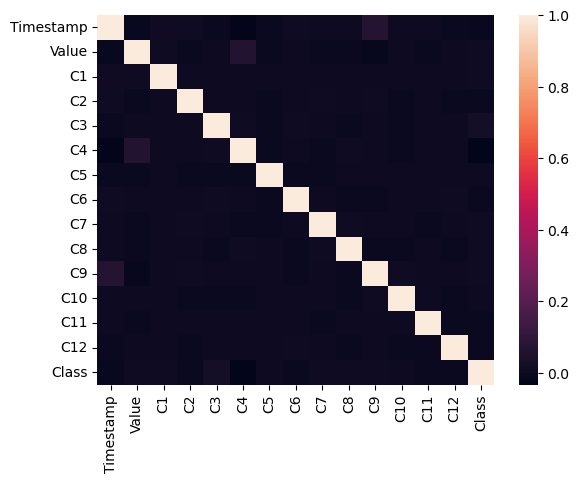

In [11]:
sns.heatmap(transaction_data.corr())

In [12]:
transaction_data.corr()

,Timestamp,Value,C1,C2,C3,C4,C5,C6,C7,C8,C9,C10,C11,C12,Class
Timestamp,1.000000,-0.010465,0.010990,0.004186,-0.001112,-0.026449,-0.005723,0.004022,0.001288,0.000226,0.067799,-0.000403,0.001204,-0.001168,-0.009994
Value,-0.010465,1.000000,0.006463,-0.001535,-0.000205,0.061557,-0.005582,0.000225,-0.001804,-0.003026,-0.014649,0.003132,-0.001535,0.003082,0.007095
C1,0.010990,0.006463,1.000000,0.002645,0.001899,0.000136,0.002116,0.001407,0.001284,0.002912,-0.000376,0.000773,0.000843,0.000137,0.007301
C2,0.004186,-0.001535,0.002645,1.000000,0.002597,0.001642,-0.001658,0.000866,0.004249,0.000065,0.004493,-0.000713,0.000900,-0.003174,-0.001013
C3,-0.001112,-0.000205,0.001899,0.002597,1.000000,0.005303,-0.001218,0.006360,0.001056,-0.001402,0.003368,-0.000885,0.002448,0.002028,0.023299
C4,-0.026449,0.061557,0.000136,0.001642,0.005303,1.000000,-0.003174,0.002643,-0.000741,0.003894,0.002401,-0.001671,0.000261,0.001615,-0.032692
C5,-0.005723,-0.005582,0.002116,-0.001658,-0.001218,-0.003174,1.000000,-0.001140,-0.005153,0.002597,0.000955,0.002331,0.002178,0.003266,0.002595
C6,0.004022,0.000225,0.001407,0.000866,0.006360,0.002643,-0.001140,1.000000,0.002850,-0.003772,-0.001691,-0.000009,0.001180,0.005680,-0.003851
C7,0.001288,-0.001804,0.001284,0.004249,0.001056,-0.000741,-0.005153,0.002850,1.000000,0.006721,0.003435,0.000374,-0.002095,0.000720,0.006152
C8,0.000226,-0.003026,0.002912,0.000065,-0.001402,0.003894,0.002597,-0.003772,0.006721,1.000000,-0.002122,-0.000996,0.002828,-0.000902,0.004237


### Target variable class distribution 

In [13]:
transaction_data['Class'].value_counts()

Class
0    139747
1       253
Name: count, dtype: int64

### We need to find out contamination amount for isolation forest

In [14]:
Fraud = transaction_data[transaction_data['Class']==1]

Valid = transaction_data[transaction_data['Class']==0]

contamination = len(Fraud)/float(len(Valid))

In [15]:
print(contamination)

print("Fraud Class : {}".format(len(Fraud)))

print("Normal Class : {}".format(len(Valid)))

0.0018104145348379571
Fraud Class : 253
Normal Class : 139747


In [16]:
contamination

0.0018104145348379571

### Data Modelling with Isolation Forest

In [17]:
X = transaction_data.drop('Class',axis=1)

In [18]:
y = transaction_data['Class']

In [19]:
clf=IsolationForest(n_estimators=500, max_samples=len(X),contamination=0.0018)

In [20]:
clf.fit(X)


IsolationForest(contamination=0.0018, max_samples=140000, n_estimators=500)

In [21]:
scores_prediction = clf.decision_function(X)

In [22]:
scores_prediction

array([0.158388  , 0.13211881, 0.13790451, ..., 0.13747685, 0.1654836 ,
       0.15867355])

<Axes: >

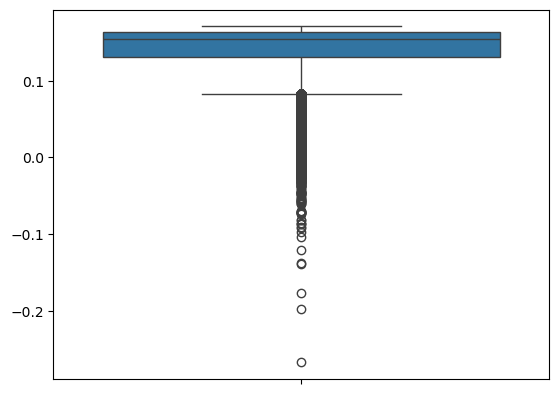

In [23]:
sns.boxplot(scores_prediction)

(array([1.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
        0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
        0.0000e+00, 1.0000e+00, 0.0000e+00, 0.0000e+00, 1.0000e+00,
        0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
        2.0000e+00, 0.0000e+00, 0.0000e+00, 1.0000e+00, 0.0000e+00,
        0.0000e+00, 1.0000e+00, 1.0000e+00, 4.0000e+00, 3.0000e+00,
        1.0000e+00, 8.0000e+00, 2.0000e+00, 8.0000e+00, 6.0000e+00,
        1.0000e+01, 8.0000e+00, 1.5000e+01, 2.9000e+01, 3.6000e+01,
        3.6000e+01, 4.4000e+01, 6.4000e+01, 6.9000e+01, 8.9000e+01,
        1.2700e+02, 1.4100e+02, 2.0800e+02, 2.7500e+02, 3.3400e+02,
        4.0300e+02, 4.4300e+02, 5.8800e+02, 7.5100e+02, 8.6100e+02,
        1.0790e+03, 1.3960e+03, 1.8230e+03, 2.5630e+03, 3.4720e+03,
        4.3590e+03, 5.3120e+03, 6.1810e+03, 6.5450e+03, 7.1360e+03,
        8.3840e+03, 1.1374e+04, 1.8196e+04, 2.9869e+04, 2.7740e+04]),
 array([-0.26637125, -0.26013005, -0.25388885,

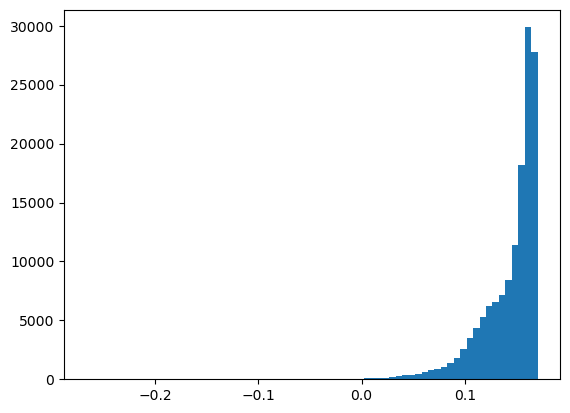

In [24]:
plt.hist(scores_prediction,bins=70)

In [25]:
transaction_data['scores'] = scores_prediction

In [26]:
transaction_data

,Timestamp,Value,C1,C2,C3,C4,C5,C6,C7,C8,C9,C10,C11,C12,Class,scores
0,152212.22220,1.816,13.245219,-0.019520,16.367516,0.029326,1.278423,2.748137,-1.331457,0.065879,-0.104518,-0.037517,-250.000000,-0.475633,0,0.158388
1,159074.44440,163.568,4.401403,0.084682,-313.000000,0.001888,-0.103762,1.115678,0.023023,0.062966,0.130546,-0.303582,-0.019975,0.007491,0,0.132119
2,43127.77778,24.000,-9.067399,0.762501,-1.739613,0.052481,-0.101681,-88.000000,0.117912,-0.005629,0.358812,-0.367016,-0.019975,361.000000,0,0.137905
3,156042.22220,8.000,8.728304,-0.382673,-1.739613,-0.116056,-0.122346,-44.000000,-338.000000,0.042154,-0.261259,-0.103974,-0.019975,-1.654373,0,0.124821
4,154720.00000,59.496,7.657141,0.150611,-1.739613,-0.034883,0.826100,0.357556,0.147640,-0.005629,0.080491,-0.693792,-0.308631,0.563570,0,0.165058
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
139995,183231.11110,102.680,26.000000,-0.230035,-7.050312,0.017126,0.101611,2.443864,-0.068998,0.159159,-0.106062,0.342779,-0.011073,0.809047,0,0.161138
139996,169976.66670,9.848,5.329287,-0.151293,8.303946,-0.004504,-0.040837,1.323421,0.083422,0.007135,-0.179373,-0.157173,0.318506,-1.106630,0,0.164349
139997,40377.77778,3.072,-4.025570,-0.468904,-275.000000,0.014959,0.296391,0.609542,0.070729,-0.005629,0.029990,0.438644,-0.026816,-0.107358,0,0.137477
139998,58136.66667,12.800,-7.357232,0.319784,-6.087797,0.018416,0.167421,0.279868,-0.018847,-0.005629,-0.228823,0.215016,-0.027304,-1.354674,0,0.165484


In [27]:
transaction_data.query('scores< 0.0019')

,Timestamp,Value,C1,C2,C3,C4,C5,C6,C7,C8,C9,C10,C11,C12,Class,scores
910,45451.111110,0.792,-1826.000000,-0.032859,-7.865014,-0.012218,-433.000000,-0.792182,-0.005377,-0.007043,-0.374519,1.255514,-1792.000000,-0.287705,0,-0.045426
1193,45897.777780,0.608,64.555098,-2.327810,-489.000000,-0.135890,0.000903,3.789328,1138.000000,0.526672,-0.345878,-0.700862,0.208750,-0.430966,1,0.001860
1398,105873.333300,15128.000,77.000000,-4.517892,-43.917155,0.268036,-15.840229,-8.221799,-19.583504,-0.329947,-0.810383,-0.712189,-3.985156,29.000000,0,-0.175868
1446,129866.666700,720.000,10.856407,-461.000000,6.782110,-0.002840,-0.812546,0.235329,-0.842303,-0.007872,-0.110698,-490.000000,492.000000,-0.114063,0,-0.019340
1596,7543.333333,0.712,-2.074055,91.000000,-419.000000,0.015368,0.000903,1.335144,0.071893,-425.000000,-0.356277,-0.260871,-0.434156,-0.087704,0,-0.009415
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
139217,30408.888890,1.216,1691.000000,-0.746950,-1.851944,0.014905,0.048262,-0.895650,0.023023,0.052473,-0.208837,0.042148,-1975.000000,-872.000000,0,-0.015419
139237,150303.333300,159.920,-6.073986,0.295812,16.684429,0.040521,-482.000000,1133.000000,-0.147470,0.009568,0.021088,-466.000000,-0.504127,-0.340892,0,-0.029748
139530,90080.000000,118.400,-1.267381,-425.000000,11.620774,0.041058,-0.221097,-1785.000000,0.104905,-0.005629,-0.193661,-334.000000,-0.094434,0.354757,0,-0.020959
139533,149737.777800,7.992,-1.250014,-0.100398,-2.582168,0.005482,-0.117542,1650.000000,0.107475,0.008159,0.046580,-467.000000,-0.019975,1662.000000,0,-0.013275
